In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

print("Total training samples:", info.splits['train'].num_examples)
print("Total test samples:", info.splits['test'].num_examples)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I14X5I_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I14X5I_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.I14X5I_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Total training samples: 25000
Total test samples: 25000


In [ ]:
# Extract raw texts and labels into lists
train_texts = []
train_labels = []
for text, label in train_data:
    train_texts.append(text.numpy().decode('utf-8'))
    train_labels.append(label.numpy())

test_texts = []
test_labels = []
for text, label in test_data:
    test_texts.append(text.numpy().decode('utf-8'))
    test_labels.append(label.numpy())



In [ ]:
# Tokenize the texts
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)



In [ ]:
# Convert to sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)



In [ ]:
# Pad sequences
max_length = 250
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')



In [ ]:
# Convert labels to numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)


In [ ]:
model = Sequential([
    Embedding(10000, 16, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_padded, train_labels,
    epochs=10,
    validation_data=(test_padded, test_labels),
    verbose=2
)

Epoch 1/10
782/782 - 6s - 7ms/step - accuracy: 0.7320 - loss: 0.5442 - val_accuracy: 0.7774 - val_loss: 0.4438
Epoch 2/10
782/782 - 7s - 9ms/step - accuracy: 0.8694 - loss: 0.3200 - val_accuracy: 0.8657 - val_loss: 0.3248
Epoch 3/10
782/782 - 8s - 11ms/step - accuracy: 0.8948 - loss: 0.2622 - val_accuracy: 0.8721 - val_loss: 0.3114
Epoch 4/10
782/782 - 7s - 9ms/step - accuracy: 0.9104 - loss: 0.2280 - val_accuracy: 0.8517 - val_loss: 0.3444
Epoch 5/10
782/782 - 6s - 7ms/step - accuracy: 0.9221 - loss: 0.2023 - val_accuracy: 0.8488 - val_loss: 0.3559
Epoch 6/10
782/782 - 10s - 13ms/step - accuracy: 0.9293 - loss: 0.1856 - val_accuracy: 0.8682 - val_loss: 0.3273
Epoch 7/10
782/782 - 7s - 9ms/step - accuracy: 0.9358 - loss: 0.1733 - val_accuracy: 0.8679 - val_loss: 0.3356
Epoch 8/10
782/782 - 6s - 7ms/step - accuracy: 0.9380 - loss: 0.1665 - val_accuracy: 0.8638 - val_loss: 0.3503
Epoch 9/10
782/782 - 8s - 10ms/step - accuracy: 0.9456 - loss: 0.1481 - val_accuracy: 0.8576 - val_loss: 0.37

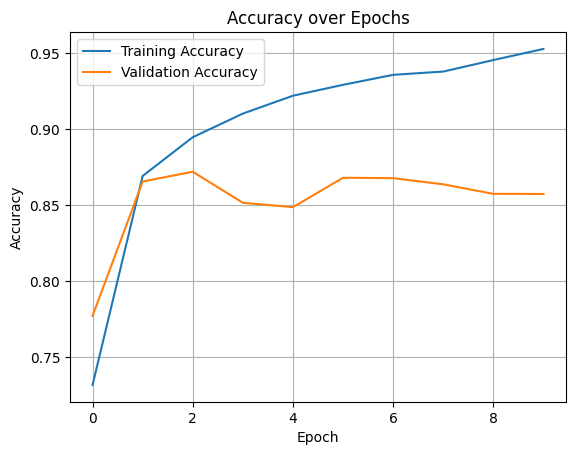

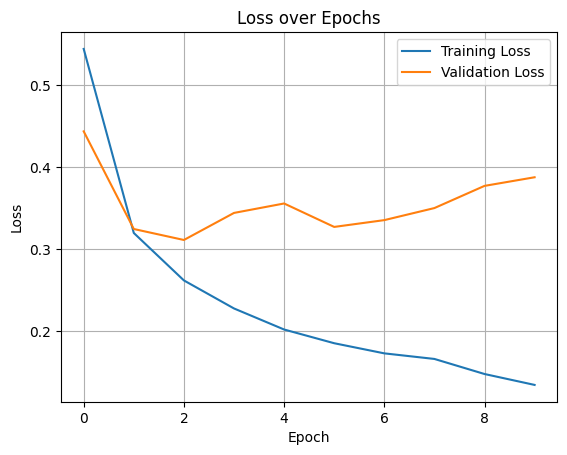

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def predict_sentiment(text):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post')
    prediction = model.predict(padded)[0][0]
    print(" Review:", text)
    print("Sentiment:", "Positive" if prediction > 0.5 else "Negative", f"({prediction:.2f})")

# Example
predict_sentiment("This movie was absolutely wonderful! Loved the acting.")
predict_sentiment("Worst movie ever. It was so boring and predictable.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
 Review: This movie was absolutely wonderful! Loved the acting.
Sentiment: Positive (0.95)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
 Review: Worst movie ever. It was so boring and predictable.
Sentiment: Negative (0.03)


In [ ]:
model.save("sentiment_model_imdb.h5")
